# Tests Statistiques : Linear Congruential Generator (LCG)

In [1]:
import sys
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

sys.path.append(os.path.abspath('../generators'))

from lcg import LCG

# Configuration
N = 50000
SEED = 42

# Initialisation de l'instance
lcg_instance = LCG(seed=SEED)

# Génération des 50 000 échantillons (convertis en octets 0-255)
data_lcg = [lcg_instance.next() % 256 for _ in range(N)]

print(f"Génération terminée : {len(data_lcg)} échantillons récupérés.")
print(f"Aperçu des 5 premiers : {data_lcg[:5]}")

Génération terminée : 50000 échantillons récupérés.
Aperçu des 5 premiers : [129, 236, 91, 254, 69]


## 1. Test d'Uniformité (Histogramme)

L'histogramme permet de visualiser si chaque valeur de l'intervalle $[0, 255]$ a la même probabilité d'apparaître. 
Une distribution parfaite doit suivre la ligne rouge théorique.

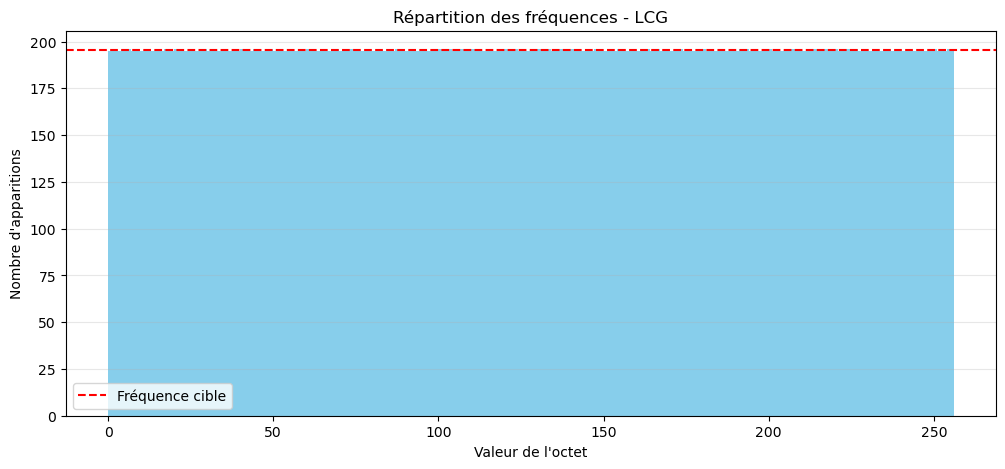

In [2]:
plt.figure(figsize=(12, 5))
plt.hist(data_lcg, bins=256, range=(0, 256), color='skyblue', edgecolor='none')
plt.axhline(y=N/256, color='red', linestyle='--', label='Fréquence cible')

plt.title("Répartition des fréquences - LCG")
plt.xlabel("Valeur de l'octet")
plt.ylabel("Nombre d'apparitions")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 2. Analyse de l'Entropie de Shannon



In [3]:
def calculate_entropy(data):
    _, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))

entropy_val = calculate_entropy(data_lcg)
print(f"Entropie calculée : {entropy_val:.5f} bits/octet")
print(f"Efficacité : {(entropy_val / 8.0) * 100:.2f}%")

Entropie calculée : 8.00000 bits/octet
Efficacité : 100.00%


## 3. Test Statistique du $\chi^2$ (Chi-carré)

Le test du $\chi^2$ vérifie mathématiquement si l'écart à l'uniformité est acceptable. 
On utilise un seuil de confiance $\alpha = 0.05$. Si la p-value est $> 0.05$, le test est réussi.

In [4]:
obs, _ = np.histogram(data_lcg, bins=256, range=(0, 256))
stat, p_value = chisquare(obs)

print(f"Statistique Chi2 : {stat:.2f}")
print(f"P-value : {p_value:.5f}")

if p_value > 0.05:
    print("Verdict : Uniformité validée.")
else:
    print("Verdict : Échec du test d'uniformité.")

Statistique Chi2 : 0.28
P-value : 1.00000
Verdict : Uniformité validée.


## 4 Analyse de l'Autocorrélation



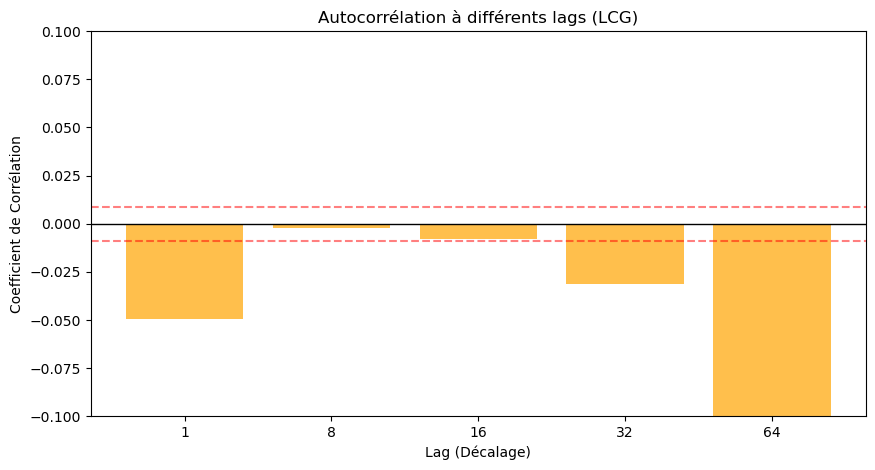

Lag 1 : -0.049628
Lag 8 : -0.002158
Lag 16 : -0.007872
Lag 32 : -0.031119
Lag 64 : -0.125054


In [5]:
def plot_autocorr(data, lags=[1, 8, 16, 32, 64]):
    corrs = [np.corrcoef(data[:-lag], data[lag:])[0, 1] for lag in lags]
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar([str(l) for l in lags], corrs, color='orange', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    plt.axhline(y=1.96/np.sqrt(len(data)), color='red', linestyle='--', alpha=0.5)
    plt.axhline(y=-1.96/np.sqrt(len(data)), color='red', linestyle='--', alpha=0.5)
    
    plt.title("Autocorrélation à différents lags (LCG)")
    plt.ylabel("Coefficient de Corrélation")
    plt.xlabel("Lag (Décalage)")
    plt.ylim(-0.1, 0.1)
    plt.show()

    for l, c in zip(lags, corrs):
        print(f"Lag {l} : {c:.6f}")

plot_autocorr(data_lcg)

## 4. Test de Kolmogorov-Smirnov (KS)



In [6]:
from scipy.stats import kstest

data_norm = np.array(data_lcg) / 255.0

statistic_ks, p_value_ks = kstest(data_norm, 'uniform')

print(f"Statistique KS : {statistic_ks:.5f}")
print(f"P-value KS : {p_value_ks:.5f}")

if p_value_ks > 0.05:
    print("\nVerdict : L'hypothèse nulle d'uniformité ne peut être rejetée (Succès).")
else:
    print("\nVerdict : Écart significatif par rapport à l'uniformité détecté (Échec).")

Statistique KS : 0.00392
P-value KS : 0.42485

Verdict : L'hypothèse nulle d'uniformité ne peut être rejetée (Succès).
